# Hazard CONUS Grid - Hail x Solar - Full-M1 Selected-Cell M2-M4 Smoke

**Peril:** hail - **Asset:** canonical solar - **Layer:** M2-M4 smoke

This notebook is the first M2-M4 smoke run that consumes the **full-CONUS MRMS-only M1** artifact:

```text
full-CONUS MRMS-only M1
  -> selected representative cells
  -> selected-cell M0 daily event samples
  -> M2 canonical solar coupling
  -> M3 hail damage
  -> M4 annual loss vectors and provisional risk metrics
```

## What this is

This is a **selected-cell smoke test** for the CONUS grid product. It proves that the full M1 artifact can
produce the comparable metric family we need: EAL, VaR, PML, TVaR, AEP/OEP curves, dollars, and percent of
TIV.

## What this is not

This is **not** a final reportable hail risk layer. The source is `MRMS_ONLY`, the severity is raw/provisional
MESH, and the tail policy is still under review. Every output from this notebook must carry that caveat.

Cross-reference:

- `docs/extra/discussion/conus_grid/hail/03_mrms_tail_qa_and_m1_policy.md`
- `docs/plans/hazard_conus_grid/hail/v1_mrms_only_grid_build.md`
- `docs/plans/hazard_conus_grid/output_schema.md`
- `docs/principles/notebook_work/exploratory_data_notebooks.md`

## 0 - Imports, paths, and fixed assumptions

Canonical solar assumption for grid comparison:

| Field | Value | Meaning / base |
|---|---:|---|
| `capacity_mw` | 100 | Fixed canonical solar plant size for every grid cell. |
| `asset_area_km2` | 1.5 | Dense 100 MW footprint used for areal hit probability. |
| `tiv_usd_per_kwp` | 1,483 | Same TIV basis used in the Hayhurst solar work. |
| `tiv_usd` | 148.3M | `100 MW * 1000 kW/MW * 1,483 USD/kWp`. |

The count process is `poisson_v1_default` from M1. That is acceptable for smoke/screening, not a final
frequency model.

In [1]:
from __future__ import annotations

import json
import math
import os
import subprocess
from datetime import timezone, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

# M4 engine is the shared, peril/asset-agnostic package (extracted verbatim from this notebook in
# Phase A; behaviour-identical, proven by shared/tests/test_engine_reproduces_smoke.py).
from risk_engine.engine import exceedance_metrics, run_cell_mc, weighted_quantile

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 120})


def repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise FileNotFoundError("repo root not found")


ROOT = repo_root()

M1_RUN_ID = os.environ.get("HAZARD_CONUS_GRID_M1_RUN_ID", "20260618T040000Z_m1_mrms_only")
M0_RECONCILED_RUN_ID = os.environ.get("MRMS_M0_RECONCILED_RUN_ID", "20260616T225000Z_m0_full_conus_reconciled")
SMOKE_RUN_ID = os.environ.get(
    "HAZARD_CONUS_GRID_SOLAR_SMOKE_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ_m2_m4_selected_cell_smoke"),
)
UPLOAD_TO_GCS = os.environ.get("HAZARD_CONUS_GRID_UPLOAD_TO_GCS", "0").lower() in {"1", "true", "yes"}
FORCE_OUTPUT = os.environ.get("HAZARD_CONUS_GRID_FORCE_OUTPUT", "0").lower() in {"1", "true", "yes"}

HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail" / "v1_mrms_only"
M1_ROOT = HAIL_GRID_DIR / "m1_hazard_layer" / f"run_id={M1_RUN_ID}"
M0_RECONCILED_ROOT = HAIL_GRID_DIR / "m0_reconciled_daily_cell_evidence" / f"run_id={M0_RECONCILED_RUN_ID}"
SOLAR_ROOT = (
    ROOT
    / "data"
    / "hazard_conus_grid"
    / "hail"
    / "solar"
    / "v1_mrms_only"
    / "m2_m4_selected_cell_smoke"
    / f"run_id={SMOKE_RUN_ID}"
)
TABLE_DIR = SOLAR_ROOT / "tables"
MAP_DIR = SOLAR_ROOT / "maps"

M1_PARQUET = M1_ROOT / "tables" / f"mrms_v1_m1_hazard_layer_{M1_RUN_ID}.parquet"
DAMAGE_CURVE_JSON = ROOT / "data" / "hail" / "damage_curves" / "hail_solar_asset_capex_weighted.json"

GCS_ROOT = (
    "gs://infrasure-benchmark/hazard_conus_grid/dev/hail/solar/v1_mrms_only/"
    f"m2_m4_selected_cell_smoke/run_id={SMOKE_RUN_ID}"
)

CELL_SELECTION_CSV = TABLE_DIR / f"mrms_v1_solar_smoke_cell_selection_{SMOKE_RUN_ID}.csv"
DAILY_PANEL_CSV = TABLE_DIR / f"mrms_v1_solar_smoke_selected_cell_daily_panel_{SMOKE_RUN_ID}.csv"
EVENT_SET_CSV = TABLE_DIR / f"mrms_v1_solar_smoke_event_set_{SMOKE_RUN_ID}.csv"
METRICS_CSV = TABLE_DIR / f"mrms_v1_solar_smoke_metrics_{SMOKE_RUN_ID}.csv"
METADATA_JSON = SOLAR_ROOT / f"metadata_{SMOKE_RUN_ID}.json"
ANNUAL_VECTORS_PARQUET = TABLE_DIR / f"mrms_v1_solar_smoke_annual_vectors_{SMOKE_RUN_ID}.parquet"

CANONICAL_SOLAR = {
    "asset_type": "solar",
    "capacity_mw": 100.0,
    "asset_area_km2": 1.5,
    "tiv_usd_per_kwp": 1483.0,
}
CANONICAL_SOLAR["tiv_usd"] = (
    CANONICAL_SOLAR["capacity_mw"] * 1000.0 * CANONICAL_SOLAR["tiv_usd_per_kwp"]
)

MC_YEARS = int(os.environ.get("HAZARD_CONUS_GRID_MC_YEARS", "250000"))
SEED = 20260618
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200, 250, 500]
SEVERITY_POLICIES = {
    "raw_mrms": {"cap_mm": None, "description": "raw MRMS MESH; preserved for audit, provisional for loss"},
    "cap_100mm_sensitivity": {
        "cap_mm": 100.0,
        "description": "diagnostic cap at 100 mm to test whether metrics are tail artifacts",
    },
}

for directory in [TABLE_DIR, MAP_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("M1 input:", M1_PARQUET.relative_to(ROOT))
print("M0 daily input:", M0_RECONCILED_ROOT.relative_to(ROOT))
print("smoke run:", SMOKE_RUN_ID)
print("local output:", SOLAR_ROOT.relative_to(ROOT))
print("gcs output:", GCS_ROOT)
print(
    "canonical solar:",
    f"{CANONICAL_SOLAR['capacity_mw']:.0f} MW,",
    f"{CANONICAL_SOLAR['asset_area_km2']:.1f} km2,",
    f"TIV ${CANONICAL_SOLAR['tiv_usd']/1e6:.1f}M",
)

M1 input: data/hazard_conus_grid/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only/tables/mrms_v1_m1_hazard_layer_20260618T040000Z_m1_mrms_only.parquet
M0 daily input: data/hazard_conus_grid/hail/v1_mrms_only/m0_reconciled_daily_cell_evidence/run_id=20260616T225000Z_m0_full_conus_reconciled
smoke run: 20260618T045301Z_m2_m4_selected_cell_smoke
local output: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke
gcs output: gs://infrasure-benchmark/hazard_conus_grid/dev/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke
canonical solar: 100 MW, 1.5 km2, TIV $148.3M


## 1 - Load full M1 and select smoke cells

The selected cells are not a climatology sample. They are an engineering smoke set chosen to exercise five
downstream behaviors:

| Role | Why it is included |
|---|---|
| `central_corridor_body` | A credible high-hail Plains cell without raw-MESH tail QA. |
| `moderate_body` | A typical body-distribution cell near the M1 median severe-day count. |
| `no_severe` | Zero-event handling; should produce zero loss metrics. |
| `high_frequency_suspicious` | A cell with extreme frequency diagnostics; should carry QA warnings. |
| `tail_qa` | A cell with raw MESH tail QA; tests raw-vs-capped severity sensitivity. |

In [2]:
m1 = pd.read_parquet(M1_PARQUET)

selected_roles = [
    {
        "role": "central_corridor_body",
        "cell_id": 302001,
        "selection_reason": "Kansas/Plains high severe-day cell, raw_mesh_body_only, no >=300 mm tail flag.",
    },
    {
        "role": "moderate_body",
        "cell_id": 276114,
        "selection_reason": "Near-median severe-day count, body-only raw MESH, useful baseline behavior.",
    },
    {
        "role": "no_severe",
        "cell_id": 306280,
        "selection_reason": "Zero severe hail days; verifies zero-event and zero-loss handling.",
    },
    {
        "role": "high_frequency_suspicious",
        "cell_id": 273305,
        "selection_reason": "Highest M1 severe-day frequency; intentionally included as a QA stress case.",
    },
    {
        "role": "tail_qa",
        "cell_id": 281823,
        "selection_reason": "Raw MESH tail-QA cell with multiple >=300 mm cell-days; tests severity guardrail.",
    },
]

selection = pd.DataFrame(selected_roles).merge(m1, on="cell_id", how="left", validate="one_to_one")
if selection["hazard"].isna().any():
    missing = selection.loc[selection["hazard"].isna(), "cell_id"].tolist()
    raise ValueError(f"selected cells not found in M1: {missing}")

selection["m2_m4_readiness"] = np.where(
    selection["role"].isin(["central_corridor_body", "moderate_body", "no_severe"]),
    "normal_smoke_input",
    "qa_stress_input",
)
selection["metrics_status"] = "provisional_smoke_not_reportable"

display(
    selection[
        [
            "role",
            "cell_id",
            "lat_center",
            "lon_center",
            "state_abbr",
            "n_severe_hail_days",
            "lambda_cell_raw",
            "max_mesh_mm_raw_any_day",
            "mesh_p95_mm_raw_on_severe_days",
            "extreme_mesh_cell_day_count",
            "severity_magnitude_status",
            "fano_phi_complete_years",
            "selection_reason",
        ]
    ]
)

CELL_SELECTION_CSV.write_text(
    selection.to_csv(index=False),
)
print("wrote selection:", CELL_SELECTION_CSV.relative_to(ROOT))
print(
    "Takeaway: these cells deliberately include normal, zero, suspicious-frequency, and tail-QA cases. "
    "They are not the final production sampling scheme."
)

,role,cell_id,lat_center,lon_center,state_abbr,n_severe_hail_days,lambda_cell_raw,max_mesh_mm_raw_any_day,mesh_p95_mm_raw_on_severe_days,extreme_mesh_cell_day_count,severity_magnitude_status,fano_phi_complete_years,selection_reason
0,central_corridor_body,302001,37.75,-99.75,KS,68,11.992757,120.800003,82.044998,0,raw_mesh_body_only,0.398305,"Kansas/Plains high severe-day cell, raw_mesh_b..."
1,moderate_body,276114,42.25,-91.50,IA,9,1.587277,33.400002,32.959999,0,raw_mesh_body_only,1.125000,"Near-median severe-day count, body-only raw ME..."
2,no_severe,306280,37.00,-110.00,AZ,0,0.000000,25.100000,NaN,0,no_severe_days,NaN,Zero severe hail days; verifies zero-event and...
3,high_frequency_suspicious,273305,42.75,-73.75,NY,255,44.972839,217.699997,85.540001,0,raw_mesh_body_only,70.796875,Highest M1 severe-day frequency; intentionally...
4,tail_qa,281823,41.25,-104.25,WY,26,4.585466,718.400024,450.250000,3,raw_mesh_tail_requires_qa,1.083333,Raw MESH tail-QA cell with multiple >=300 mm c...


wrote selection: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke/tables/mrms_v1_solar_smoke_cell_selection_20260618T045301Z_m2_m4_selected_cell_smoke.csv
Takeaway: these cells deliberately include normal, zero, suspicious-frequency, and tail-QA cases. They are not the final production sampling scheme.


## 2 - Pull selected-cell daily M0 rows

M1 is one row per cell, but M2-M4 needs an event sample. For this smoke run, the event sample is the set of
M0 severe cell-days for the selected cells.

Important base:

- one M0 row = one `cell_id x source_date`;
- one smoke event sample = one selected-cell day where `hail_day_flag == True`;
- `mesh_max_mm` is raw daily cell-max MESH, not de-biased hailstone size;
- `severe_area_km2_approx` is severe native-pixel count treated as an approximate km2 footprint inside the
  cell.

In [3]:
selected_cell_ids = set(selection["cell_id"].astype(int))
m0_columns = [
    "hazard",
    "cell_id",
    "date",
    "source_product",
    "source_key",
    "source_timestamp",
    "threshold_mm",
    "lat_center",
    "lon_center",
    "state_abbr",
    "iso_rto",
    "n_native_pixels_observed",
    "n_native_pixels_positive",
    "n_native_pixels_severe",
    "severe_area_km2_approx",
    "mesh_max_mm",
    "mesh_mean_severe_mm",
    "mesh_p50_severe_mm",
    "mesh_p90_severe_mm",
    "mesh_p95_severe_mm",
    "hail_day_flag",
    "coverage_status",
    "qa_flags",
]

frames: list[pd.DataFrame] = []
files = sorted(M0_RECONCILED_ROOT.glob("date=*/part-000.parquet"))
if not files:
    raise FileNotFoundError(f"no M0 daily partitions found under {M0_RECONCILED_ROOT}")

for file in files:
    df = pq.ParquetFile(file).read(columns=m0_columns).to_pandas()
    sub = df.loc[df["cell_id"].isin(selected_cell_ids)].copy()
    if len(sub):
        frames.append(sub)

daily_panel = pd.concat(frames, ignore_index=True)
daily_panel["date"] = pd.to_datetime(daily_panel["date"])
daily_panel = daily_panel.merge(
    selection[["cell_id", "role", "selection_reason", "severity_magnitude_status"]],
    on="cell_id",
    how="left",
    validate="many_to_one",
)
daily_panel = daily_panel.sort_values(["role", "date"]).reset_index(drop=True)

expected_rows = len(selected_cell_ids) * int(selection["n_source_dates"].max())
assert len(daily_panel) == expected_rows, f"expected {expected_rows:,} selected daily rows, got {len(daily_panel):,}"

DAILY_PANEL_CSV.write_text(daily_panel.to_csv(index=False))

status = (
    daily_panel.groupby(["role", "coverage_status"], observed=False)
    .size()
    .rename("days")
    .reset_index()
    .sort_values(["role", "coverage_status"])
)
display(status)
print(f"selected daily rows: {len(daily_panel):,}")
print(f"selected severe cell-day samples: {int(daily_panel['hail_day_flag'].sum()):,}")
print("wrote daily panel:", DAILY_PANEL_CSV.relative_to(ROOT))
print("Takeaway: the event sample comes from full-record M0, not from the old four-cell pilot.")

,role,coverage_status,days
0,central_corridor_body,observed_no_hail,1610
1,central_corridor_body,observed_severe_hail,68
2,central_corridor_body,observed_sub_severe_hail,393
3,high_frequency_suspicious,observed_no_hail,1042
4,high_frequency_suspicious,observed_severe_hail,255
5,high_frequency_suspicious,observed_sub_severe_hail,774
6,moderate_body,observed_no_hail,1798
7,moderate_body,observed_severe_hail,9
8,moderate_body,observed_sub_severe_hail,264
9,no_severe,observed_no_hail,2046


selected daily rows: 10,355
selected severe cell-day samples: 358
wrote daily panel: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke/tables/mrms_v1_solar_smoke_selected_cell_daily_panel_20260618T045301Z_m2_m4_selected_cell_smoke.csv
Takeaway: the event sample comes from full-record M0, not from the old four-cell pilot.


## 3 - M2 coupling for canonical solar

Grid M2 does not use a 50-mile site radius. The hazard bucket is the benchmark cell. For each selected severe
cell-day:

```text
F_proxy = severe native-pixel area inside the cell
A_proxy = observed native-pixel area inside the cell
s_solar = canonical solar footprint area
p_hit = min((sqrt(F_proxy) + sqrt(s_solar))^2 / A_proxy, 1)
```

`p_hit` is only the hit probability. It is not multiplied into loss at M3; it becomes the Bernoulli hit/miss
draw inside M4.

In [4]:
events = daily_panel.loc[daily_panel["hail_day_flag"].astype(bool)].copy()
events = events.sort_values(["role", "date"]).reset_index(drop=True)
events["event_id"] = (
    "cell_"
    + events["cell_id"].astype(str)
    + "_"
    + events["date"].dt.strftime("%Y%m%d")
)

asset_area = float(CANONICAL_SOLAR["asset_area_km2"])
footprint = events["severe_area_km2_approx"].astype(float).clip(lower=0.0)
cell_area = events["n_native_pixels_observed"].astype(float).clip(lower=1.0)
events["cell_area_km2_proxy"] = cell_area
events["footprint_area_km2_proxy"] = footprint
events["p_hit_solar"] = np.minimum((np.sqrt(footprint) + math.sqrt(asset_area)) ** 2 / cell_area, 1.0)
events["m2_coupling_basis"] = "Minkowski areal hit probability inside 0.25 degree grid cell"

display(
    events.groupby("role", observed=False)
    .agg(
        event_samples=("event_id", "count"),
        mean_p_hit=("p_hit_solar", "mean"),
        max_p_hit=("p_hit_solar", "max"),
        max_mesh_mm=("mesh_max_mm", "max"),
        max_severe_pixels=("n_native_pixels_severe", "max"),
    )
    .reset_index()
)
print("Takeaway: p_hit is stochastic coupling; M3 still emits full conditional loss if a hit occurs.")

,role,event_samples,mean_p_hit,max_p_hit,max_mesh_mm,max_severe_pixels
0,central_corridor_body,68,0.056079,0.533141,120.800003,290
1,high_frequency_suspicious,255,0.022345,0.041579,217.699997,15
2,moderate_body,9,0.043808,0.185387,33.400002,91
3,tail_qa,26,0.073535,0.325500,718.400024,170


Takeaway: p_hit is stochastic coupling; M3 still emits full conditional loss if a hit occurs.


## 4 - M3 damage under raw and capped severity policies

This notebook intentionally runs two policies:

| Policy | Meaning | Use decision |
|---|---|---|
| `raw_mrms` | Uses raw daily cell-max MESH. | Audit/provisional only; not final. |
| `cap_100mm_sensitivity` | Caps the damage-driving MESH at 100 mm. | Diagnostic guardrail; not final calibration. |

The cap is deliberately a **sensitivity**, not a claim about true hail size. Its job is to show whether M4
metrics are controlled by the raw-MESH tail.

,role,severity_policy,samples,max_raw_mesh_mm,max_mesh_for_damage_mm,mean_damage_ratio,max_damage_ratio,mean_cond_loss_pct_tiv,max_cond_loss_pct_tiv
0,central_corridor_body,cap_100mm_sensitivity,68,120.800003,100.000000,0.063558,0.330833,0.063558,0.330833
1,central_corridor_body,raw_mrms,68,120.800003,120.800003,0.063937,0.342117,0.063937,0.342117
2,high_frequency_suspicious,cap_100mm_sensitivity,255,217.699997,100.000000,0.061945,0.330833,0.061945,0.330833
3,high_frequency_suspicious,raw_mrms,255,217.699997,217.699997,0.062215,0.344000,0.062215,0.344000
4,moderate_body,cap_100mm_sensitivity,9,33.400002,33.400002,0.013331,0.018520,0.013331,0.018520
5,moderate_body,raw_mrms,9,33.400002,33.400002,0.013331,0.018520,0.013331,0.018520
6,tail_qa,cap_100mm_sensitivity,26,718.400024,100.000000,0.093690,0.330833,0.093690,0.330833
7,tail_qa,raw_mrms,26,718.400024,718.400024,0.095209,0.344000,0.095209,0.344000


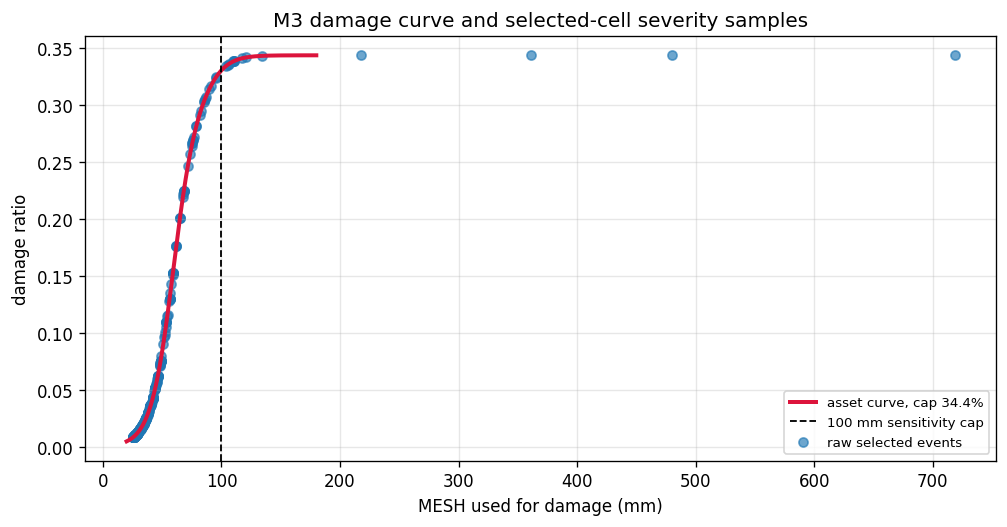

damage curve: hail/solar__asset__capex_weighted | cap 34.4% of TIV | TIV $148.3M
Takeaway: M3 emits full conditional loss. p_hit remains separate until M4.


In [5]:
curve = json.loads(DAMAGE_CURVE_JSON.read_text())
subsystems = curve["subsystems"]


def logistic(x: np.ndarray | float, L: float, k: float, x0: float) -> np.ndarray:
    return L / (1.0 + np.exp(-k * (np.asarray(x, dtype="float64") - x0)))


def damage_ratio(size_mm: np.ndarray | float) -> np.ndarray:
    return sum(
        s["capex_weight"] * logistic(size_mm, s["L"], s["k"], s["x0"])
        for s in subsystems
    )


curve_cap = float(sum(s["capex_weight"] * s["L"] for s in subsystems))
policy_frames: list[pd.DataFrame] = []
for policy_name, policy in SEVERITY_POLICIES.items():
    e = events.copy()
    cap_mm = policy["cap_mm"]
    e["severity_policy"] = policy_name
    e["severity_policy_description"] = policy["description"]
    e["mesh_for_damage_mm"] = e["mesh_max_mm"].astype(float)
    if cap_mm is not None:
        e["mesh_for_damage_mm"] = e["mesh_for_damage_mm"].clip(upper=float(cap_mm))
    e["mesh_cap_mm"] = cap_mm
    e["damage_ratio"] = damage_ratio(e["mesh_for_damage_mm"])
    e["conditional_loss_usd"] = e["damage_ratio"] * CANONICAL_SOLAR["tiv_usd"]
    e["conditional_loss_pct_tiv"] = e["damage_ratio"]
    e["m3_damage_basis"] = (
        "capex-weighted solar hail damage curve applied to policy-specific MESH input"
    )
    policy_frames.append(e)

event_set = pd.concat(policy_frames, ignore_index=True) if policy_frames else pd.DataFrame()

display(
    event_set.groupby(["role", "severity_policy"], observed=False)
    .agg(
        samples=("event_id", "count"),
        max_raw_mesh_mm=("mesh_max_mm", "max"),
        max_mesh_for_damage_mm=("mesh_for_damage_mm", "max"),
        mean_damage_ratio=("damage_ratio", "mean"),
        max_damage_ratio=("damage_ratio", "max"),
        mean_cond_loss_pct_tiv=("conditional_loss_pct_tiv", "mean"),
        max_cond_loss_pct_tiv=("conditional_loss_pct_tiv", "max"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
grid = np.linspace(20, 180, 400)
ax.plot(grid, damage_ratio(grid), color="crimson", lw=2.4, label=f"asset curve, cap {curve_cap:.1%}")
ax.axvline(100, color="black", ls="--", lw=1.1, label="100 mm sensitivity cap")
if len(event_set):
    raw_only = event_set.loc[event_set["severity_policy"].eq("raw_mrms")]
    ax.scatter(raw_only["mesh_max_mm"], raw_only["damage_ratio"], s=30, alpha=0.65, label="raw selected events")
ax.set(
    title="M3 damage curve and selected-cell severity samples",
    xlabel="MESH used for damage (mm)",
    ylabel="damage ratio",
)
ax.legend(fontsize=8)
plt.tight_layout()
damage_plot = MAP_DIR / f"mrms_v1_solar_smoke_damage_curve_{SMOKE_RUN_ID}.png"
plt.savefig(damage_plot, bbox_inches="tight")
plt.show()

print(
    f"damage curve: {curve['curve_id']} | cap {curve_cap:.1%} of TIV | "
    f"TIV ${CANONICAL_SOLAR['tiv_usd']/1e6:.1f}M"
)
print("Takeaway: M3 emits full conditional loss. p_hit remains separate until M4.")

## 5 - M4 helper functions

M4 follows the same discipline as the site-specific hail workflow:

- draw annual event counts from `lambda_cell_raw`;
- sample observed event rows for that cell;
- draw `Bernoulli(p_hit_solar)`;
- apply full conditional loss on hit;
- sum annual aggregate loss for AEP;
- take annual max occurrence loss for OEP;
- cap annual aggregate loss at TIV;
- read EAL, VaR, PML, and TVaR from the annual vectors.

In [6]:
# weighted_quantile, run_cell_mc, and exceedance_metrics are imported from the shared `risk_engine`
# package (top of notebook). They were extracted verbatim from this notebook in Phase A and are
# behaviour-identical (proven by shared/tests/test_engine_reproduces_smoke.py: max rel diff ~2e-16).
# The engine is array-based and asset/peril-agnostic; this driver supplies the per-event arrays and
# canonical-asset scalars (capacity_kwp, tiv_usd) at the call sites below.
print("M4 engine imported from risk_engine.engine")

helpers ready


## 6 - Run selected-cell M4

The QA checks verify the engine shape:

- annual aggregate loss is at least annual occurrence loss;
- uncapped Monte Carlo EAL is close to analytic `lambda * mean(p_hit * conditional_loss)`;
- zero-loss years match Poisson thinning within tolerance;
- capped EAL never exceeds uncapped EAL.

In [7]:
metrics_rows: list[dict[str, object]] = []
annual_frames: list[pd.DataFrame] = []
check_rows: list[dict[str, object]] = []

for _, cell in selection.sort_values("role").iterrows():
    cell_id = int(cell["cell_id"])
    lambda_cell = float(cell["lambda_cell_raw"])

    for policy_name in SEVERITY_POLICIES:
        cell_events = event_set.loc[
            event_set["cell_id"].eq(cell_id) & event_set["severity_policy"].eq(policy_name)
        ].copy()
        rng = np.random.default_rng(SEED + cell_id + (0 if policy_name == "raw_mrms" else 10_000_000))
        aep, oep, aep_uncapped, counts = run_cell_mc(
            p_hit=cell_events["p_hit_solar"].to_numpy(dtype="float64"),
            conditional_loss_usd=cell_events["conditional_loss_usd"].to_numpy(dtype="float64"),
            lambda_cell=lambda_cell,
            n_years=MC_YEARS,
            tiv_usd=CANONICAL_SOLAR["tiv_usd"],
            rng=rng,
        )

        annual_frames.append(
            pd.DataFrame(
                {
                    "sim_year": np.arange(MC_YEARS, dtype="int32"),
                    "cell_id": cell_id,
                    "role": cell["role"],
                    "severity_policy": policy_name,
                    "aep_usd": aep,
                    "oep_usd": oep,
                    "aep_uncapped_usd": aep_uncapped,
                }
            )
        )

        if cell_events.empty:
            mean_p_hit = 0.0
            lambda_asset = 0.0
            cond_loss_mean = float("nan")
            cond_loss_p50 = float("nan")
            cond_loss_p95 = float("nan")
            cond_loss_p99 = float("nan")
            cond_loss_max = float("nan")
            analytic_uncapped_eal = 0.0
        else:
            p_evt = cell_events["p_hit_solar"].to_numpy(dtype="float64")
            loss_evt = cell_events["conditional_loss_usd"].to_numpy(dtype="float64")
            mean_p_hit = float(np.mean(p_evt))
            lambda_asset = lambda_cell * mean_p_hit
            cond_loss_mean = float(np.average(loss_evt, weights=p_evt)) if p_evt.sum() > 0 else float("nan")
            cond_loss_p50 = weighted_quantile(loss_evt, p_evt, 0.50)
            cond_loss_p95 = weighted_quantile(loss_evt, p_evt, 0.95)
            cond_loss_p99 = weighted_quantile(loss_evt, p_evt, 0.99)
            cond_loss_max = float(np.max(loss_evt))
            analytic_uncapped_eal = lambda_cell * float(np.mean(p_evt * loss_evt))

        metric = exceedance_metrics(
            aep,
            oep,
            CANONICAL_SOLAR["tiv_usd"],
            capacity_kwp=CANONICAL_SOLAR["capacity_mw"] * 1000.0,
            return_periods=RETURN_PERIODS,
        )
        uncapped_mc_eal = float(np.mean(aep_uncapped))
        cap_binding_fraction = float(np.mean(aep_uncapped > CANONICAL_SOLAR["tiv_usd"]))
        uncapped_eal_rel_error = (
            abs(uncapped_mc_eal - analytic_uncapped_eal) / analytic_uncapped_eal
            if analytic_uncapped_eal > 0
            else abs(uncapped_mc_eal - analytic_uncapped_eal)
        )
        zero_loss_expected = math.exp(-lambda_asset) if lambda_asset > 0 else 1.0
        zero_tolerance = 0.03 if lambda_asset > 0 else 1e-12
        eal_tolerance = 0.05 if analytic_uncapped_eal > 0 else 1e-12
        qa_checks_pass = bool(
            (aep + 1e-9 >= oep).all()
            and uncapped_eal_rel_error <= eal_tolerance
            and metric["eal_usd"] <= uncapped_mc_eal + 1e-6
            and abs(float(np.mean(aep == 0)) - zero_loss_expected) <= zero_tolerance
        )

        qa_flags = [
            "mrms_only_v1",
            "selected_cell_smoke",
            "provisional_severity",
            "not_reportable",
            "poisson_v1_default",
            "raw_mrms_mesh_input",
            "cell_clipped_footprint_proxy",
        ]
        if bool(cell["zero_hail_flag"]):
            qa_flags.append("zero_observed_severe_days")
        if str(cell["severity_magnitude_status"]) == "raw_mesh_tail_requires_qa":
            qa_flags.append("severity_tail_requires_qa")
        if str(cell["role"]) == "high_frequency_suspicious":
            qa_flags.append("frequency_spike_review")
        if policy_name != "raw_mrms":
            qa_flags.append("severity_cap_sensitivity")

        row: dict[str, object] = {
            "hazard": "hail",
            "asset_type": "solar",
            "risk_run_id": SMOKE_RUN_ID,
            "m1_run_id": M1_RUN_ID,
            "m0_reconciled_run_id": M0_RECONCILED_RUN_ID,
            "cell_id": cell_id,
            "role": cell["role"],
            "lat_center": cell["lat_center"],
            "lon_center": cell["lon_center"],
            "state_abbr": cell["state_abbr"],
            "iso_rto": cell["iso_rto"],
            "capacity_mw": CANONICAL_SOLAR["capacity_mw"],
            "asset_area_km2": CANONICAL_SOLAR["asset_area_km2"],
            "tiv_usd": CANONICAL_SOLAR["tiv_usd"],
            "tiv_usd_per_kwp": CANONICAL_SOLAR["tiv_usd_per_kwp"],
            "lambda_cell": lambda_cell,
            "lambda_cell_basis": "n_severe_hail_days / observed_years from MRMS-only M1",
            "mean_p_hit": mean_p_hit,
            "lambda_asset": lambda_asset,
            "freq_dist_used": "poisson_v1_default",
            "freq_fit_status": cell["freq_fit_status"],
            "severity_policy": policy_name,
            "severity_policy_description": SEVERITY_POLICIES[policy_name]["description"],
            "severity_magnitude_status": cell["severity_magnitude_status"],
            "size_dist_status": cell["size_dist_status"],
            "mc_years": MC_YEARS,
            "n_observed_days": int(cell["n_observed_days"]),
            "n_observed_severe_hail_days": int(cell["n_severe_hail_days"]),
            "n_smoke_event_samples": int(len(cell_events)),
            "max_raw_mesh_mm_any_day": float(cell["max_mesh_mm_raw_any_day"]),
            "extreme_mesh_cell_day_count": int(cell["extreme_mesh_cell_day_count"]),
            "cond_loss_mean_usd": cond_loss_mean,
            "cond_loss_p50_usd": cond_loss_p50,
            "cond_loss_p95_usd": cond_loss_p95,
            "cond_loss_p99_usd": cond_loss_p99,
            "cond_loss_max_usd": cond_loss_max,
            "cond_loss_mean_pct_tiv": cond_loss_mean / CANONICAL_SOLAR["tiv_usd"]
            if np.isfinite(cond_loss_mean)
            else float("nan"),
            "cond_loss_p50_pct_tiv": cond_loss_p50 / CANONICAL_SOLAR["tiv_usd"]
            if np.isfinite(cond_loss_p50)
            else float("nan"),
            "cond_loss_p95_pct_tiv": cond_loss_p95 / CANONICAL_SOLAR["tiv_usd"]
            if np.isfinite(cond_loss_p95)
            else float("nan"),
            "cond_loss_p99_pct_tiv": cond_loss_p99 / CANONICAL_SOLAR["tiv_usd"]
            if np.isfinite(cond_loss_p99)
            else float("nan"),
            "cond_loss_max_pct_tiv": cond_loss_max / CANONICAL_SOLAR["tiv_usd"]
            if np.isfinite(cond_loss_max)
            else float("nan"),
            "analytic_uncapped_eal_usd": analytic_uncapped_eal,
            "mc_uncapped_eal_usd": uncapped_mc_eal,
            "cap_binding_fraction": cap_binding_fraction,
            "qa_checks_pass": qa_checks_pass,
            "qa_uncapped_eal_rel_error": uncapped_eal_rel_error,
            "qa_zero_loss_expected_poisson_thinning": zero_loss_expected,
            "qa_flags": ";".join(qa_flags),
            "metrics_status": "provisional_selected_cell_smoke_not_reportable",
            "allowed_use": "screening, interface validation, selected-cell smoke",
            "not_allowed_use": "final calibrated hail climatology or reportable EAL/PML/VaR/TVaR",
            "provenance_m1_layer": str(M1_PARQUET.relative_to(ROOT)),
            "provenance_m0_daily": str(M0_RECONCILED_ROOT.relative_to(ROOT)),
            "damage_curve_id": curve["curve_id"],
        }
        row.update(metric)
        metrics_rows.append(row)
        check_rows.append(
            {
                "role": cell["role"],
                "cell_id": cell_id,
                "severity_policy": policy_name,
                "analytic_uncapped_eal_usd": analytic_uncapped_eal,
                "mc_uncapped_eal_usd": uncapped_mc_eal,
                "mc_capped_eal_usd": metric["eal_usd"],
                "uncapped_eal_rel_error": uncapped_eal_rel_error,
                "cap_binding_fraction": cap_binding_fraction,
                "zero_loss_observed": float(np.mean(aep == 0)),
                "zero_loss_expected": zero_loss_expected,
                "aep_ge_oep": bool((aep + 1e-9 >= oep).all()),
                "qa_checks_pass": qa_checks_pass,
            }
        )

metrics = pd.DataFrame(metrics_rows)
checks = pd.DataFrame(check_rows)
annual_vectors = pd.concat(annual_frames, ignore_index=True)

display(
    metrics[
        [
            "role",
            "severity_policy",
            "cell_id",
            "lambda_cell",
            "mean_p_hit",
            "lambda_asset",
            "eal_pct_tiv",
            "var99_pct_tiv",
            "pml100_pct_tiv",
            "pml250_pct_tiv",
            "pml500_pct_tiv",
            "tvar99_pct_tiv",
            "zero_loss_fraction",
            "qa_checks_pass",
        ]
    ].sort_values(["role", "severity_policy"])
)
display(checks)

assert checks["qa_checks_pass"].all(), "one or more M4 smoke QA checks failed"
print("Takeaway: M4 engine checks pass for all selected cells and both severity policies.")

,role,severity_policy,cell_id,lambda_cell,mean_p_hit,lambda_asset,eal_pct_tiv,var99_pct_tiv,pml100_pct_tiv,pml250_pct_tiv,pml500_pct_tiv,tvar99_pct_tiv,zero_loss_fraction,qa_checks_pass
1,central_corridor_body,cap_100mm_sensitivity,302001,11.992757,0.056079,0.672542,0.090567,0.613644,0.613644,0.686725,0.759910,0.712730,0.512144,True
0,central_corridor_body,raw_mrms,302001,11.992757,0.056079,0.672542,0.091443,0.612586,0.612586,0.691261,0.775242,0.721457,0.511624,True
3,high_frequency_suspicious,cap_100mm_sensitivity,273305,44.972839,0.022345,1.004937,0.077165,0.519464,0.519464,0.637950,0.675128,0.628166,0.365724,True
2,high_frequency_suspicious,raw_mrms,273305,44.972839,0.022345,1.004937,0.077298,0.520424,0.520424,0.639521,0.683901,0.632505,0.367252,True
5,moderate_body,cap_100mm_sensitivity,276114,1.587277,0.043808,0.069535,0.001112,0.018520,0.018520,0.018520,0.028083,0.019559,0.933628,True
4,moderate_body,raw_mrms,276114,1.587277,0.043808,0.069535,0.001128,0.018520,0.018520,0.018520,0.027974,0.019535,0.932604,True
7,no_severe,cap_100mm_sensitivity,306280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,True
6,no_severe,raw_mrms,306280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,True
9,tail_qa,cap_100mm_sensitivity,281823,4.585466,0.073535,0.337194,0.061088,0.590895,0.590895,0.636506,0.661666,0.650676,0.713152,True
8,tail_qa,raw_mrms,281823,4.585466,0.073535,0.337194,0.061808,0.590895,0.590895,0.649673,0.688000,0.662658,0.713728,True


,role,cell_id,severity_policy,analytic_uncapped_eal_usd,mc_uncapped_eal_usd,mc_capped_eal_usd,uncapped_eal_rel_error,cap_binding_fraction,zero_loss_observed,zero_loss_expected,aep_ge_oep,qa_checks_pass
0,central_corridor_body,302001,raw_mrms,1.358190e+07,1.356539e+07,1.356099e+07,0.001215,0.000376,0.511624,0.510409,True,True
1,central_corridor_body,302001,cap_100mm_sensitivity,1.350109e+07,1.343410e+07,1.343112e+07,0.004962,0.000180,0.512144,0.510409,True,True
2,high_frequency_suspicious,273305,raw_mrms,1.152535e+07,1.146456e+07,1.146322e+07,0.005274,0.000060,0.367252,0.366068,True,True
3,high_frequency_suspicious,273305,cap_100mm_sensitivity,1.147214e+07,1.144417e+07,1.144358e+07,0.002438,0.000068,0.365724,0.366068,True,True
4,moderate_body,276114,raw_mrms,1.666770e+05,1.672284e+05,1.672284e+05,0.003308,0.000000,0.932604,0.932827,True,True
5,moderate_body,276114,cap_100mm_sensitivity,1.666770e+05,1.648613e+05,1.648613e+05,0.010894,0.000000,0.933628,0.932827,True,True
6,no_severe,306280,raw_mrms,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,1.000000,True,True
7,no_severe,306280,cap_100mm_sensitivity,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,1.000000,True,True
8,tail_qa,281823,raw_mrms,9.144557e+06,9.167170e+06,9.166151e+06,0.002473,0.000064,0.713728,0.713770,True,True
9,tail_qa,281823,cap_100mm_sensitivity,9.035794e+06,9.060603e+06,9.059357e+06,0.002746,0.000064,0.713152,0.713770,True,True


Takeaway: M4 engine checks pass for all selected cells and both severity policies.


## 7 - Visual readout

These plots are QA plots. They show that the risk metric schema is populated and that the severity policy is
explicit. They do not make final geography claims.

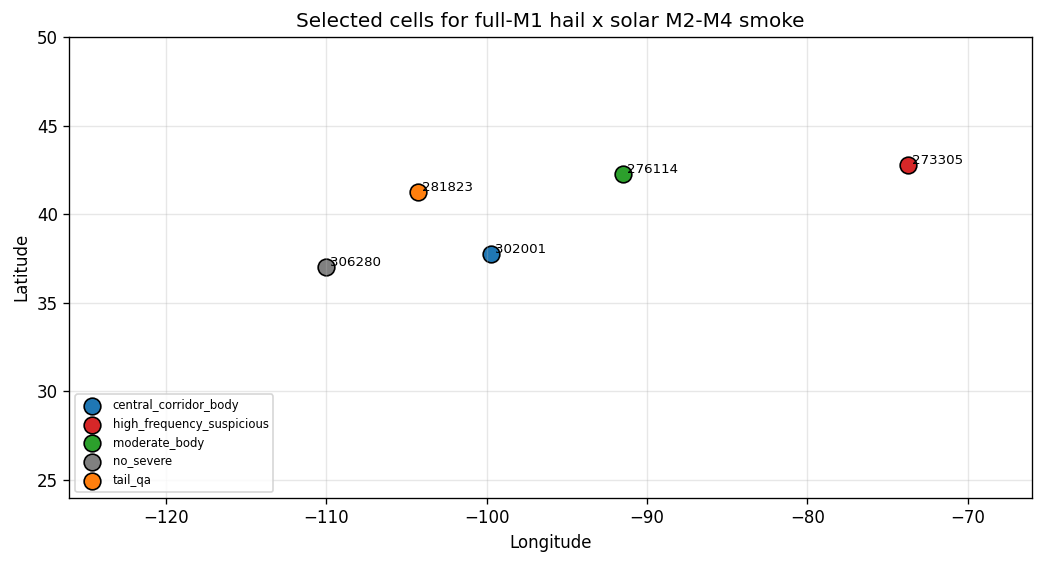

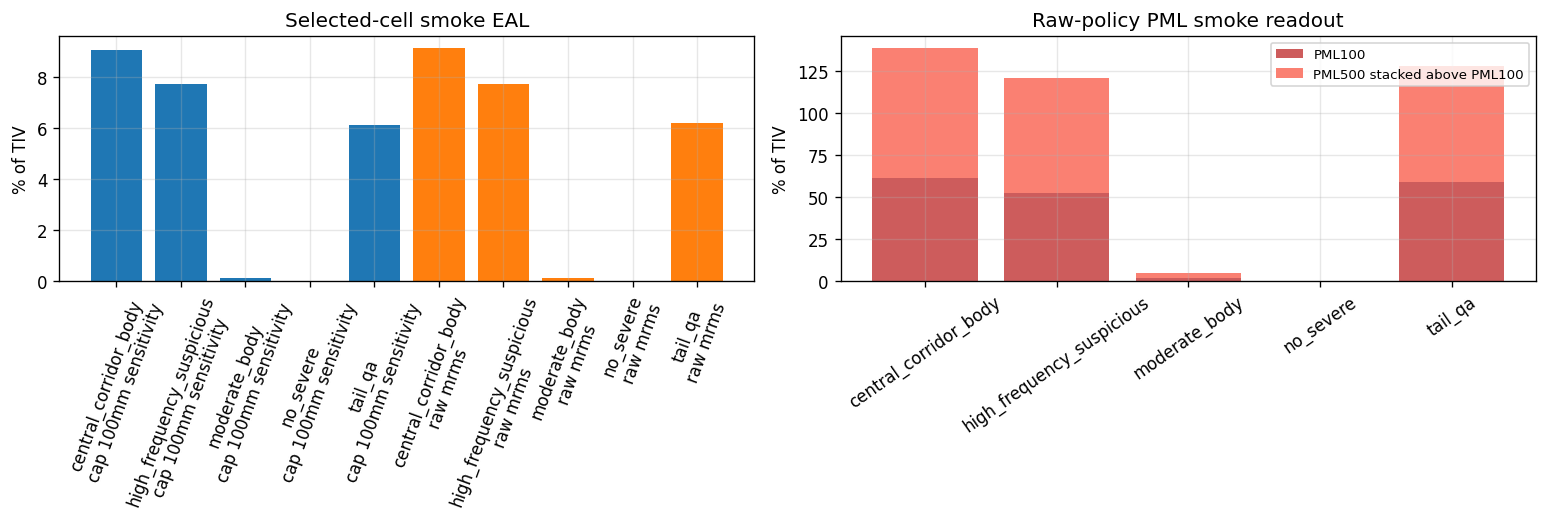

Takeaway: the comparable metric family is present, but every metric remains provisional.


In [8]:
selection_plot = selection.copy()
role_colors = {
    "central_corridor_body": "tab:blue",
    "moderate_body": "tab:green",
    "no_severe": "gray",
    "high_frequency_suspicious": "tab:red",
    "tail_qa": "tab:orange",
}

fig, ax = plt.subplots(figsize=(8.8, 4.8))
for role, group in selection_plot.groupby("role", observed=False):
    ax.scatter(
        group["lon_center"],
        group["lat_center"],
        s=100,
        label=role,
        color=role_colors.get(role, "black"),
        edgecolor="black",
    )
for _, row in selection_plot.iterrows():
    ax.text(row["lon_center"] + 0.25, row["lat_center"] + 0.08, str(row["cell_id"]), fontsize=8)
ax.set(
    title="Selected cells for full-M1 hail x solar M2-M4 smoke",
    xlabel="Longitude",
    ylabel="Latitude",
    xlim=(-126, -66),
    ylim=(24, 50),
)
ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()
cell_map_png = MAP_DIR / f"mrms_v1_solar_smoke_selected_cells_{SMOKE_RUN_ID}.png"
plt.savefig(cell_map_png, bbox_inches="tight")
plt.show()

plot_metrics = metrics.sort_values(["role", "severity_policy"]).copy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for policy, group in plot_metrics.groupby("severity_policy", observed=False):
    ax[0].bar(
        group["role"] + "\n" + policy.replace("_", " "),
        group["eal_pct_tiv"] * 100,
        label=policy,
    )
ax[0].set(title="Selected-cell smoke EAL", ylabel="% of TIV", xlabel="")
ax[0].tick_params(axis="x", rotation=70)

raw_metrics = plot_metrics.loc[plot_metrics["severity_policy"].eq("raw_mrms")]
ax[1].bar(raw_metrics["role"], raw_metrics["pml100_pct_tiv"] * 100, color="indianred", label="PML100")
ax[1].bar(
    raw_metrics["role"],
    raw_metrics["pml500_pct_tiv"] * 100,
    bottom=raw_metrics["pml100_pct_tiv"] * 100,
    color="salmon",
    label="PML500 stacked above PML100",
)
ax[1].set(title="Raw-policy PML smoke readout", ylabel="% of TIV", xlabel="")
ax[1].tick_params(axis="x", rotation=35)
ax[1].legend(fontsize=8)
plt.tight_layout()
metrics_plot_png = MAP_DIR / f"mrms_v1_solar_smoke_metric_readout_{SMOKE_RUN_ID}.png"
plt.savefig(metrics_plot_png, bbox_inches="tight")
plt.show()

print("Takeaway: the comparable metric family is present, but every metric remains provisional.")

## 8 - Persist outputs

Small CSV/JSON outputs are the review handoff. The annual vectors are audit artifacts and should remain
gitignored.

In [9]:
event_cols = [
    "event_id",
    "role",
    "cell_id",
    "date",
    "severity_policy",
    "mesh_max_mm",
    "mesh_for_damage_mm",
    "mesh_cap_mm",
    "footprint_area_km2_proxy",
    "cell_area_km2_proxy",
    "p_hit_solar",
    "n_native_pixels_severe",
    "mesh_mean_severe_mm",
    "mesh_p50_severe_mm",
    "mesh_p90_severe_mm",
    "mesh_p95_severe_mm",
    "damage_ratio",
    "conditional_loss_usd",
    "conditional_loss_pct_tiv",
    "m2_coupling_basis",
    "m3_damage_basis",
]

event_set[event_cols].to_csv(EVENT_SET_CSV, index=False)
metrics.to_csv(METRICS_CSV, index=False)
annual_vectors.to_parquet(ANNUAL_VECTORS_PARQUET, index=False)

metadata = {
    "artifact_family": "mrms_v1_hail_solar_selected_cell_m2_m4_smoke",
    "status": "created",
    "risk_run_id": SMOKE_RUN_ID,
    "m1_run_id": M1_RUN_ID,
    "m0_reconciled_run_id": M0_RECONCILED_RUN_ID,
    "source_set": "MRMS_ONLY",
    "version": "V1",
    "hazard": "hail",
    "asset_type": "solar",
    "canonical_asset": CANONICAL_SOLAR,
    "mc_years": MC_YEARS,
    "count_model": "poisson_v1_default from M1",
    "severity_policies": SEVERITY_POLICIES,
    "selected_cells": selection[
        [
            "role",
            "cell_id",
            "lat_center",
            "lon_center",
            "state_abbr",
            "lambda_cell_raw",
            "n_severe_hail_days",
            "severity_magnitude_status",
            "selection_reason",
        ]
    ].to_dict(orient="records"),
    "outputs": {
        "cell_selection_csv": str(CELL_SELECTION_CSV.relative_to(ROOT)),
        "daily_panel_csv": str(DAILY_PANEL_CSV.relative_to(ROOT)),
        "event_set_csv": str(EVENT_SET_CSV.relative_to(ROOT)),
        "metrics_csv": str(METRICS_CSV.relative_to(ROOT)),
        "annual_vectors_parquet": str(ANNUAL_VECTORS_PARQUET.relative_to(ROOT)),
        "maps": [str(p.relative_to(ROOT)) for p in sorted(MAP_DIR.glob("*.png"))],
    },
    "metrics_status": "provisional_selected_cell_smoke_not_reportable",
    "allowed_use": [
        "screening",
        "interface validation",
        "selected-cell M2-M4 smoke",
        "raw-vs-capped severity sensitivity review",
    ],
    "not_allowed_use": [
        "final calibrated hail climatology",
        "reportable EAL/PML/VaR/TVaR",
        "pricing or underwriting decisions",
        "full-CONUS risk scaleout without another review gate",
    ],
    "qa": {
        "all_checks_pass": bool(checks["qa_checks_pass"].all()),
        "checks": checks.to_dict(orient="records"),
    },
    "caveats": [
        "MRMS-only operational-era record.",
        "Frequency uses poisson_v1_default from M1; no full fitted over-dispersion model is used here.",
        "Severity uses raw daily cell-max MESH or a diagnostic cap; neither is final calibrated hail size.",
        "Footprint proxy is severe native-pixel area clipped to the 0.25 degree cell.",
        "Gross physical damage only; no financial terms, deductibles, limits, or business interruption.",
    ],
    "gcs_root": GCS_ROOT,
}
METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")

print("wrote event set:", EVENT_SET_CSV.relative_to(ROOT))
print("wrote metrics:", METRICS_CSV.relative_to(ROOT))
print("wrote metadata:", METADATA_JSON.relative_to(ROOT))
print("wrote annual vectors:", ANNUAL_VECTORS_PARQUET.relative_to(ROOT))

wrote event set: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke/tables/mrms_v1_solar_smoke_event_set_20260618T045301Z_m2_m4_selected_cell_smoke.csv
wrote metrics: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke/tables/mrms_v1_solar_smoke_metrics_20260618T045301Z_m2_m4_selected_cell_smoke.csv
wrote metadata: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke/metadata_20260618T045301Z_m2_m4_selected_cell_smoke.json
wrote annual vectors: data/hazard_conus_grid/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke/tables/mrms_v1_solar_smoke_annual_vectors_20260618T045301Z_m2_m4_selected_cell_smoke.parquet


## 9 - Optional GCS upload

In [10]:
def split_gcs_uri(uri: str) -> tuple[str, str]:
    if not uri.startswith("gs://"):
        raise ValueError(f"not a GCS URI: {uri}")
    rest = uri[5:]
    bucket, _, blob = rest.partition("/")
    if not bucket or not blob:
        raise ValueError(f"invalid GCS URI: {uri}")
    return bucket, blob


def gcs_prefix_exists(uri: str) -> bool:
    try:
        from google.cloud import storage  # type: ignore

        bucket_name, prefix = split_gcs_uri(uri.rstrip("/") + "/_probe")
        prefix = prefix.rsplit("/", 1)[0].rstrip("/") + "/"
        return any(storage.Client().bucket(bucket_name).list_blobs(prefix=prefix, max_results=1))
    except Exception:
        result = subprocess.run(
            ["gcloud", "storage", "ls", f"{uri.rstrip('/')}/**"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            check=False,
        )
        return result.returncode == 0


def upload_file(local_path: Path, destination_uri: str) -> None:
    try:
        from google.cloud import storage  # type: ignore

        bucket_name, blob_name = split_gcs_uri(destination_uri)
        storage.Client().bucket(bucket_name).blob(blob_name).upload_from_filename(local_path)
    except Exception:
        subprocess.run(["gcloud", "storage", "cp", str(local_path), destination_uri], check=True)


def upload_tree(local_root: Path, gcs_root: str) -> list[str]:
    if gcs_prefix_exists(gcs_root) and not FORCE_OUTPUT:
        raise FileExistsError(f"GCS prefix already exists: {gcs_root}")
    uploaded: list[str] = []
    for path in sorted(p for p in local_root.rglob("*") if p.is_file()):
        rel = path.relative_to(local_root).as_posix()
        destination = f"{gcs_root.rstrip('/')}/{rel}"
        upload_file(path, destination)
        uploaded.append(destination)
    return uploaded


if UPLOAD_TO_GCS:
    uploaded = upload_tree(SOLAR_ROOT, GCS_ROOT)
    metadata["upload_status"] = "uploaded"
    metadata["uploaded_gcs_outputs"] = uploaded
    METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
    upload_file(METADATA_JSON, f"{GCS_ROOT.rstrip('/')}/{METADATA_JSON.name}")
    print(f"uploaded {len(uploaded):,} files to {GCS_ROOT}")
else:
    metadata["upload_status"] = "not_requested"
    metadata["uploaded_gcs_outputs"] = []
    METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
    print("GCS upload not requested")

/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


...

/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


uploaded 9 files to gs://infrasure-benchmark/hazard_conus_grid/dev/hail/solar/v1_mrms_only/m2_m4_selected_cell_smoke/run_id=20260618T045301Z_m2_m4_selected_cell_smoke


## 10 - Findings and carried forward

What this smoke run proves:

- the full-CONUS M1 artifact can feed the standard M2-M4 risk-metric contract;
- `p_hit` remains stochastic and separate from conditional loss;
- zero-event cells produce zero loss metrics without special downstream hacks;
- high-frequency and tail-QA cells keep explicit QA flags;
- raw and capped severity policies can be compared side by side.

What remains before full-CONUS M2-M4:

- accept or revise the severity guardrail policy;
- decide whether the full scaleout should emit both raw and capped sensitivity rows;
- decide whether high-frequency suspicious cells need frequency QA/pooling before scaleout;
- keep all outputs labeled `MRMS_ONLY`, `V1`, `provisional severity`, and `not reportable`.